# FoldFlow-style + CFG para traducción activa ↔ inactiva

Este notebook entrena y evalúa un modelo bidireccional de **Flow Matching condicional con
Classifier-Free Guidance (CFG)** sobre pares de kinasas activas/inactivas.

**Alcance técnico.** El repositorio no contiene una implementación funcional del paquete oficial
FoldFlow (`models/load_foldflow.py` es un placeholder). Por eso se implementa aquí una variante
FoldFlow-style reproducible sobre trazas C-alpha: transporte continuo de coordenadas, alineamiento
Kabsch, campo vectorial Transformer y CFG. No modela marcos rígidos SE(3), torsiones ni átomos
completos; las conclusiones deben interpretarse dentro de esa representación.

El notebook:
- audita y deduplica el dataset;
- excluye PDB con etiquetas conflictivas o tensores inválidos;
- forma pares dentro de cada kinasa y crea ambas direcciones;
- usa splits disjuntos por `kinase_name`;
- entrena 500 epochs y guarda el mejor checkpoint;
- evalúa RMSD, MAE, MSE, distancia por residuo, TM-score aproximado y accuracy proxy;
- exporta métricas, figuras, trayectorias y coordenadas generadas.

In [2]:
from __future__ import annotations

import json, math, os, random, warnings
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any, Mapping, Sequence

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid")

def find_project_root(start: Path = Path.cwd()) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "data/metadata/kinase_labels.csv").exists() and (candidate / "data/processed").is_dir():
            return candidate
    raise FileNotFoundError(
        "No se encontró data/metadata/kinase_labels.csv junto con data/processed. "
        "Ejecutá el notebook desde la raíz del proyecto o desde notebooks/."
    )

ROOT = find_project_root()
DATA = ROOT / "data"
METADATA_PATH = DATA / "metadata" / "kinase_labels.csv"
PROCESSED_DIR = DATA / "processed"
SPLITS_DIR = DATA / "splits"
OUTPUT_DIR = ROOT / "outputs" / "foldflow_cfg_active_inactive"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
METRICS_DIR = OUTPUT_DIR / "metrics"
FIGURES_DIR = OUTPUT_DIR / "figures"
EXAMPLES_DIR = OUTPUT_DIR / "generated_examples"
for directory in [OUTPUT_DIR, CHECKPOINT_DIR, METRICS_DIR, FIGURES_DIR, EXAMPLES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

@dataclass
class Config:
    seed: int = 42
    epochs: int = 500
    batch_size: int = 12
    learning_rate: float = 3e-4
    weight_decay: float = 1e-5
    num_points: int = 256
    max_pairs_per_kinase: int = 256
    hidden_dim: int = 192
    embedding_dim: int = 32
    num_layers: int = 4
    dropout: float = 0.10
    condition_dropout: float = 0.15
    noise_std: float = 0.02
    guidance_scale: float = 2.0
    integration_steps: int = 32
    grad_clip: float = 1.0
    num_workers: int = 0
    metric_every: int = 5

CONFIG = Config()
if os.getenv("FOLDFLOW_NOTEBOOK_SMOKE", "0") == "1":
    CONFIG.epochs = 2
    CONFIG.hidden_dim = 64
    CONFIG.num_layers = 2
    CONFIG.max_pairs_per_kinase = 16
    CONFIG.integration_steps = 4
    CONFIG.metric_every = 1

def set_seed(seed: int):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed(CONFIG.seed)
DEVICE = "cuda" if torch.cuda.is_available() else (
    "mps" if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available() else "cpu"
)
print(f"Proyecto: {ROOT}")
print(f"Dispositivo: {DEVICE}")
print(f"Epochs configurados: {CONFIG.epochs}")
print(f"Outputs: {OUTPUT_DIR}")

Proyecto: /Users/josefinadehan/tp_vision_avanzada/TPF_Vision_Avanzada
Dispositivo: mps
Epochs configurados: 500
Outputs: /Users/josefinadehan/tp_vision_avanzada/TPF_Vision_Avanzada/outputs/foldflow_cfg_active_inactive


## 1. Carga y validación explícita del dataset

Un `pdb_id` puede aparecer varias veces en la metadata. Primero se detectan conflictos y luego se
conserva una sola fila por PDB. Un par biológico se define aquí como dos estructuras de la misma
`kinase_name` con estados opuestos. No hay un `pair_id` experimental más específico en los datos.

In [3]:
REQUIRED_COLUMNS = {
    "pdb_id", "kinase_name", "conformational_state", "dfg_state", "alphac_state"
}
metadata_raw = pd.read_csv(METADATA_PATH)
missing_columns = REQUIRED_COLUMNS - set(metadata_raw.columns)
if missing_columns:
    raise ValueError(f"Faltan columnas obligatorias en metadata: {sorted(missing_columns)}")

metadata_raw["pdb_id"] = metadata_raw["pdb_id"].astype(str).str.lower().str.strip()
metadata_raw["conformational_state"] = metadata_raw["conformational_state"].astype(str).str.lower().str.strip()
invalid_states = sorted(set(metadata_raw["conformational_state"]) - {"active", "inactive"})
if invalid_states:
    raise ValueError(f"Estados no soportados: {invalid_states}. Se esperan active/inactive.")

label_counts = metadata_raw.groupby("pdb_id")["conformational_state"].nunique()
conflicting_pdbs = sorted(label_counts[label_counts > 1].index)
kinase_counts = metadata_raw.groupby("pdb_id")["kinase_name"].nunique()
conflicting_kinases = sorted(kinase_counts[kinase_counts > 1].index)
if conflicting_kinases:
    raise ValueError(f"Hay PDB asignados a más de una kinasa: {conflicting_kinases[:10]}")

metadata = metadata_raw[~metadata_raw["pdb_id"].isin(conflicting_pdbs)].copy()
if "resolution" in metadata:
    metadata["_resolution"] = pd.to_numeric(metadata["resolution"], errors="coerce").fillna(np.inf)
    metadata = metadata.sort_values(["pdb_id", "_resolution"])
metadata = metadata.drop_duplicates("pdb_id", keep="first").drop(columns=["_resolution"], errors="ignore")

def tensor_path(pdb_id: str) -> Path:
    for value in [str(pdb_id).lower(), str(pdb_id).upper(), str(pdb_id)]:
        path = PROCESSED_DIR / value / "ca_coords.pt"
        if path.exists():
            return path
    return PROCESSED_DIR / str(pdb_id).lower() / "ca_coords.pt"

def safe_torch_load(path: Path):
    try:
        return torch.load(path, map_location="cpu", weights_only=True)
    except TypeError:
        return torch.load(path, map_location="cpu")

audit_rows = []
for row in tqdm(metadata.itertuples(index=False), total=len(metadata), desc="Auditando coordenadas"):
    path = tensor_path(row.pdb_id)
    reason, length = "", np.nan
    if not path.exists():
        reason = "missing_coordinates"
    else:
        try:
            coords = safe_torch_load(path).float()
            if coords.ndim != 2 or coords.shape[1] != 3:
                reason = f"invalid_shape_{tuple(coords.shape)}"
            elif not torch.isfinite(coords).all():
                reason = "non_finite_coordinates"
            else:
                length = int(coords.shape[0])
        except Exception as exc:
            reason = f"load_error_{type(exc).__name__}"
    audit_rows.append({"pdb_id": row.pdb_id, "sequence_length": length, "exclusion_reason": reason})

coordinate_audit = pd.DataFrame(audit_rows)
metadata = metadata.merge(coordinate_audit, on="pdb_id", how="left")
invalid_structures = metadata[metadata["exclusion_reason"] != ""].copy()
valid_metadata = metadata[metadata["exclusion_reason"] == ""].copy()

pairable = valid_metadata.groupby("kinase_name")["conformational_state"].agg(lambda x: set(x))
unpaired_groups = sorted(pairable[pairable.map(lambda x: not {"active", "inactive"} <= x)].index)
unpaired_proteins = valid_metadata[valid_metadata["kinase_name"].isin(unpaired_groups)].copy()
paired_metadata = valid_metadata[~valid_metadata["kinase_name"].isin(unpaired_groups)].copy()

dataset_summary = pd.DataFrame([{
    "filas_metadata_original": len(metadata_raw),
    "pdb_unicos_originales": metadata_raw["pdb_id"].nunique(),
    "pdb_conflicto_estado_excluidos": len(conflicting_pdbs),
    "estructuras_validas_pareables": len(paired_metadata),
    "muestras_activas": int((paired_metadata["conformational_state"] == "active").sum()),
    "muestras_inactivas": int((paired_metadata["conformational_state"] == "inactive").sum()),
    "kinasas_con_ambos_estados": paired_metadata["kinase_name"].nunique(),
    "estructuras_sin_coordenadas_validas": len(invalid_structures),
    "proteinas_en_grupos_sin_par": len(unpaired_proteins),
}])
display(dataset_summary)

excluded = pd.concat([
    metadata_raw[metadata_raw["pdb_id"].isin(conflicting_pdbs)].assign(exclusion_reason="conflicting_state"),
    invalid_structures,
    unpaired_proteins.assign(exclusion_reason="kinase_without_opposite_state"),
], ignore_index=True)
excluded.to_csv(METRICS_DIR / "excluded_structures.csv", index=False)
coordinate_audit.to_csv(METRICS_DIR / "coordinate_audit.csv", index=False)
dataset_summary.to_csv(METRICS_DIR / "dataset_summary.csv", index=False)

if paired_metadata.empty:
    raise RuntimeError("No existen pares activo/inactivo válidos después de la auditoría.")
print("Ejemplos de kinasas pareables:")
display(pd.crosstab(paired_metadata["kinase_name"], paired_metadata["conformational_state"]).head(10))
if conflicting_pdbs:
    warnings.warn(f"Se excluyeron {len(conflicting_pdbs)} PDB con etiquetas active/inactive conflictivas.")

Auditando coordenadas: 100%|██████████| 848/848 [00:00<00:00, 2505.99it/s]


,filas_metadata_original,pdb_unicos_originales,pdb_conflicto_estado_excluidos,estructuras_validas_pareables,muestras_activas,muestras_inactivas,kinasas_con_ambos_estados,estructuras_sin_coordenadas_validas,proteinas_en_grupos_sin_par
0,1777,863,15,848,446,402,13,0,0


Ejemplos de kinasas pareables:


conformational_state,active,inactive
kinase_name,,
ABL1,7,35
AKT1,16,17
ALK,61,3
BRAF,19,85
CDK4,3,11
CDK6,5,14
EGFR,159,102
ERBB2,2,2
FGFR1,59,1


/var/folders/cj/3myknj8n1jvcbnqjybggkqlr0000gn/T/ipykernel_14331/808228315.py:97: UserWarning: Se excluyeron 15 PDB con etiquetas active/inactive conflictivas.
  warnings.warn(f"Se excluyeron {len(conflicting_pdbs)} PDB con etiquetas active/inactive conflictivas.")


## 2. Pares bidireccionales y splits sin leakage

Se reutilizan `data/splits/*.csv` solo para recuperar la asignación por kinasa, y se verifica que sea
disjunta. Si faltan, se construye un split determinista 70/15/15 por `kinase_name`. Para evitar que
kinasas grandes dominen, el emparejamiento usa un ciclo balanceado limitado por kinasa, no el producto
cartesiano completo.

In [4]:
def load_or_create_group_split(frame: pd.DataFrame) -> dict[str, set[str]]:
    existing = {}
    for name in ["train", "val", "test"]:
        path = SPLITS_DIR / f"{name}.csv"
        if path.exists():
            split_frame = pd.read_csv(path)
            existing[name] = set(split_frame["kinase_name"].astype(str))
    if len(existing) == 3:
        return existing
    groups = sorted(frame["kinase_name"].unique())
    rng = np.random.default_rng(CONFIG.seed); rng.shuffle(groups)
    n = len(groups); n_test = max(1, round(0.15*n)); n_val = max(1, round(0.15*n))
    return {
        "test": set(groups[:n_test]),
        "val": set(groups[n_test:n_test+n_val]),
        "train": set(groups[n_test+n_val:]),
    }

split_groups = load_or_create_group_split(paired_metadata)
for left, right in [("train", "val"), ("train", "test"), ("val", "test")]:
    overlap = split_groups[left] & split_groups[right]
    if overlap:
        raise RuntimeError(f"Leakage: kinasas compartidas entre {left}/{right}: {sorted(overlap)}")

split_by_kinase = {kinase: split for split, values in split_groups.items() for kinase in values}
paired_metadata["split"] = paired_metadata["kinase_name"].map(split_by_kinase)
if paired_metadata["split"].isna().any():
    missing = sorted(paired_metadata.loc[paired_metadata["split"].isna(), "kinase_name"].unique())
    raise RuntimeError(f"Kinasas sin split asignado: {missing}")

def build_pairs(frame: pd.DataFrame, max_pairs: int, seed: int) -> pd.DataFrame:
    rng = random.Random(seed)
    rows = []
    for (split, kinase), group in frame.groupby(["split", "kinase_name"], sort=True):
        active = group[group["conformational_state"] == "active"].to_dict("records")
        inactive = group[group["conformational_state"] == "inactive"].to_dict("records")
        rng.shuffle(active); rng.shuffle(inactive)
        possible = len(active) * len(inactive)
        target = min(max(len(active), len(inactive)), possible, max_pairs)
        selected, cursor = set(), 0
        while len(selected) < target and cursor < max(1, possible * 3):
            if not active or not inactive:
                break
            a = active[cursor % len(active)]
            i = inactive[(cursor + cursor // max(1, len(active))) % len(inactive)]
            cursor += 1
            key = (a["pdb_id"], i["pdb_id"])
            if key in selected:
                continue
            selected.add(key)
            base = {
                "pair_id": f"{kinase}_{i['pdb_id']}_{a['pdb_id']}",
                "split": split, "kinase_name": kinase,
                "active_pdb": a["pdb_id"], "inactive_pdb": i["pdb_id"],
                "active_length": int(a["sequence_length"]), "inactive_length": int(i["sequence_length"]),
                "active_dfg": str(a["dfg_state"]), "inactive_dfg": str(i["dfg_state"]),
                "active_alphac": str(a["alphac_state"]), "inactive_alphac": str(i["alphac_state"]),
            }
            rows += [
                {**base, "source_pdb": i["pdb_id"], "target_pdb": a["pdb_id"],
                 "source_state": "inactive", "target_state": "active", "condition": "inactive_to_active"},
                {**base, "source_pdb": a["pdb_id"], "target_pdb": i["pdb_id"],
                 "source_state": "active", "target_state": "inactive", "condition": "active_to_inactive"},
            ]
    return pd.DataFrame(rows)

pairs = build_pairs(paired_metadata, CONFIG.max_pairs_per_kinase, CONFIG.seed)
if pairs.empty:
    raise RuntimeError("No se pudieron construir pares activo/inactivo.")
pair_counts = pairs.groupby(["split", "condition"]).size().rename("samples").reset_index()
pair_counts["biological_pairs"] = pair_counts["samples"] // 1
display(pair_counts)
display(pairs.head(6)[["pair_id", "kinase_name", "source_pdb", "source_state", "target_pdb", "target_state", "condition"]])

for split in ["train", "val", "test"]:
    if not (pairs["split"] == split).any():
        raise RuntimeError(f"El split {split} no contiene pares.")
assert not (set(pairs.query("split=='train'").kinase_name) & set(pairs.query("split=='test'").kinase_name))
pairs.to_csv(METRICS_DIR / "paired_translation_samples.csv", index=False)
pd.DataFrame([
    {"split": split, "kinases": ", ".join(sorted(values)), "n_kinases": len(values)}
    for split, values in split_groups.items()
]).to_csv(METRICS_DIR / "split_groups.csv", index=False)

,split,condition,samples,biological_pairs
0,test,active_to_inactive,103,103
1,test,inactive_to_active,103,103
2,train,active_to_inactive,442,442
3,train,inactive_to_active,442,442
4,val,active_to_inactive,120,120
5,val,inactive_to_active,120,120


,pair_id,kinase_name,source_pdb,source_state,target_pdb,target_state,condition
0,PDGFRA_8pqj_8pqi,PDGFRA,8pqj,inactive,8pqi,active,inactive_to_active
1,PDGFRA_8pqj_8pqi,PDGFRA,8pqi,active,8pqj,inactive,active_to_inactive
2,PDGFRA_6joi_8pqh,PDGFRA,6joi,inactive,8pqh,active,inactive_to_active
3,PDGFRA_6joi_8pqh,PDGFRA,8pqh,active,6joi,inactive,active_to_inactive
4,PDGFRA_8pqk_8pqi,PDGFRA,8pqk,inactive,8pqi,active,inactive_to_active
5,PDGFRA_8pqk_8pqi,PDGFRA,8pqi,active,8pqk,inactive,active_to_inactive


### Normalización estructural

Las longitudes pareadas suelen diferir. Como `ca_coords.pt` no conserva IDs de residuo, se remuestrea
cada traza a `num_points` índices equiespaciados. Luego se centra la fuente, se alinea el target a la
fuente con Kabsch y se divide por el radio RMS de la fuente. `scale` permite volver a Å.

In [5]:
NULL, UNK = "<NULL>", "<UNK>"
def make_vocab(values):
    return {value: idx for idx, value in enumerate([NULL, UNK] + sorted(set(map(str, values))))}

train_pairs = pairs[pairs["split"] == "train"]
VOCAB = {
    "state": make_vocab(["active", "inactive"]),
    "kinase": make_vocab(train_pairs["kinase_name"]),
    "dfg": make_vocab(list(train_pairs["active_dfg"]) + list(train_pairs["inactive_dfg"])),
    "alphac": make_vocab(list(train_pairs["active_alphac"]) + list(train_pairs["inactive_alphac"])),
}
def vocab_id(name, value): return VOCAB[name].get(str(value), VOCAB[name][UNK])
def load_coords(pdb_id): return safe_torch_load(tensor_path(pdb_id)).float()
def resample(coords, n):
    if len(coords) == n: return coords.clone()
    return F.interpolate(coords.T[None], size=n, mode="linear", align_corners=True)[0].T
def center(coords): return coords - coords.mean(0, keepdim=True)
def kabsch(mobile, target):
    m, t = center(mobile), center(target)
    u, _, vh = torch.linalg.svd(m.T @ t)
    rotation = u @ vh
    if torch.det(rotation) < 0:
        u[:, -1] *= -1; rotation = u @ vh
    return m @ rotation

class TranslationDataset(Dataset):
    def __init__(self, frame):
        self.frame = frame.reset_index(drop=True)
    def __len__(self): return len(self.frame)
    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        source = center(resample(load_coords(row.source_pdb), CONFIG.num_points))
        target = kabsch(resample(load_coords(row.target_pdb), CONFIG.num_points), source)
        scale = source.square().sum(-1).mean().sqrt().clamp_min(1e-6)
        source, target = source / scale, target / scale
        target_dfg = row.active_dfg if row.target_state == "active" else row.inactive_dfg
        target_alphac = row.active_alphac if row.target_state == "active" else row.inactive_alphac
        return {
            "x0": source, "x1": target, "scale": scale,
            "source_state": torch.tensor(vocab_id("state", row.source_state)),
            "target_state": torch.tensor(vocab_id("state", row.target_state)),
            "kinase": torch.tensor(vocab_id("kinase", row.kinase_name)),
            "dfg": torch.tensor(vocab_id("dfg", target_dfg)),
            "alphac": torch.tensor(vocab_id("alphac", target_alphac)),
            "pair_id": row.pair_id, "kinase_name": row.kinase_name,
            "source_pdb": row.source_pdb, "target_pdb": row.target_pdb,
            "source_state_name": row.source_state, "target_state_name": row.target_state,
            "condition": row.condition,
        }

datasets = {name: TranslationDataset(pairs[pairs["split"] == name]) for name in ["train", "val", "test"]}
loaders = {
    name: DataLoader(ds, batch_size=CONFIG.batch_size, shuffle=(name=="train"),
                     num_workers=CONFIG.num_workers, generator=torch.Generator().manual_seed(CONFIG.seed))
    for name, ds in datasets.items()
}
sample_batch = next(iter(loaders["train"]))
print("Shapes finales:")
print("input_structure:", tuple(sample_batch["x0"].shape))
print("target_structure:", tuple(sample_batch["x1"].shape))
print("source_state:", tuple(sample_batch["source_state"].shape))
print("target_state:", tuple(sample_batch["target_state"].shape))
print("scale:", tuple(sample_batch["scale"].shape))

Shapes finales:
input_structure: (12, 256, 3)
target_structure: (12, 256, 3)
source_state: (12,)
target_state: (12,)
scale: (12,)


## 3. Flow Matching + Classifier-Free Guidance

Durante entrenamiento se muestrea `t ~ U(0,1)`, se forma
`x_t=(1-t)x_source+t x_target+ruido` y se aprende la velocidad
`v*=x_target-x_source`. El dropout de condición pone a cero todo el contexto condicional en una
fracción de las muestras. En inferencia:

`v_cfg = v_uncond + guidance_scale * (v_cond - v_uncond)`.

In [6]:
class ResidualMLP(nn.Module):
    def __init__(self, dim, dropout):
        super().__init__()
        self.net = nn.Sequential(nn.LayerNorm(dim), nn.Linear(dim, 2*dim), nn.SiLU(),
                                 nn.Dropout(dropout), nn.Linear(2*dim, dim))
    def forward(self, x): return x + self.net(x)

class FoldFlowCFG(nn.Module):
    def __init__(self):
        super().__init__()
        e, h = CONFIG.embedding_dim, CONFIG.hidden_dim
        self.source_state_emb = nn.Embedding(len(VOCAB["state"]), e)
        self.target_state_emb = nn.Embedding(len(VOCAB["state"]), e)
        self.kinase_emb = nn.Embedding(len(VOCAB["kinase"]), e)
        self.dfg_emb = nn.Embedding(len(VOCAB["dfg"]), e)
        self.alphac_emb = nn.Embedding(len(VOCAB["alphac"]), e)
        self.time_net = nn.Sequential(nn.Linear(3, e), nn.SiLU(), nn.Linear(e, e))
        context_dim = 6 * e
        self.input_projection = nn.Linear(3 + context_dim + 2, h)
        self.position_embedding = nn.Parameter(torch.randn(1, CONFIG.num_points, h) * 0.01)
        heads = next(x for x in [8, 4, 2, 1] if h % x == 0)
        layer = nn.TransformerEncoderLayer(
            h, heads, 4*h, CONFIG.dropout, activation="gelu", batch_first=True, norm_first=True
        )
        self.body = nn.TransformerEncoder(layer, CONFIG.num_layers)
        self.output = nn.Sequential(nn.LayerNorm(h), nn.Linear(h, 3))

    def context(self, batch, force_unconditional=False, training_drop=False):
        batch_size = batch["target_state"].shape[0]
        if force_unconditional:
            keep = torch.zeros(batch_size, 1, device=batch["target_state"].device)
        elif training_drop:
            keep = (torch.rand(batch_size, 1, device=batch["target_state"].device)
                    >= CONFIG.condition_dropout).float()
        else:
            keep = torch.ones(batch_size, 1, device=batch["target_state"].device)
        values = [
            self.source_state_emb(batch["source_state"]),
            self.target_state_emb(batch["target_state"]),
            self.kinase_emb(batch["kinase"]),
            self.dfg_emb(batch["dfg"]),
            self.alphac_emb(batch["alphac"]),
        ]
        return torch.cat([value * keep for value in values], dim=-1)

    def forward(self, x, t, batch, force_unconditional=False, training_drop=False):
        t = t.reshape(-1, 1)
        time = self.time_net(torch.cat([t, torch.sin(2*math.pi*t), torch.cos(2*math.pi*t)], -1))
        context = torch.cat([time, self.context(batch, force_unconditional, training_drop)], -1)
        context = context[:, None].expand(-1, x.shape[1], -1)
        position = torch.linspace(0, 1, x.shape[1], device=x.device)
        position = torch.stack([position, torch.sin(2*math.pi*position)], -1)[None].expand(x.shape[0], -1, -1)
        hidden = self.input_projection(torch.cat([x, context, position], -1))
        hidden = self.body(hidden + self.position_embedding[:, :x.shape[1]])
        return self.output(hidden)

def move_batch(batch, device=DEVICE):
    return {key: value.to(device) if torch.is_tensor(value) else value for key, value in batch.items()}

def flow_loss(model, batch, training=True):
    x0, x1 = batch["x0"], batch["x1"]
    t = torch.rand(len(x0), device=x0.device)
    xt = (1-t[:,None,None])*x0 + t[:,None,None]*x1
    if training and CONFIG.noise_std > 0:
        xt = xt + CONFIG.noise_std * torch.randn_like(xt)
    target_velocity = x1 - x0
    prediction = model(xt, t, batch, training_drop=training)
    return F.mse_loss(prediction, target_velocity)

@torch.no_grad()
def guided_velocity(model, x, t, batch, guidance_scale):
    cond = model(x, t, batch)
    if guidance_scale == 1.0: return cond
    uncond = model(x, t, batch, force_unconditional=True)
    return uncond + guidance_scale * (cond - uncond)

@torch.no_grad()
def integrate(model, batch, guidance_scale=None, steps=None, save_times=(0,.25,.5,.75,1)):
    guidance_scale = CONFIG.guidance_scale if guidance_scale is None else guidance_scale
    steps = CONFIG.integration_steps if steps is None else steps
    x = batch["x0"].clone()
    result = {0.0: x.detach().cpu()}
    dt = 1.0 / steps
    for step in range(steps):
        t0v, t1v = step/steps, (step+1)/steps
        t0 = torch.full((len(x),), t0v, device=x.device)
        t1 = torch.full((len(x),), t1v, device=x.device)
        v0 = guided_velocity(model, x, t0, batch, guidance_scale)
        predictor = x + dt*v0
        v1 = guided_velocity(model, predictor, t1, batch, guidance_scale)
        x = x + .5*dt*(v0+v1)
        for requested in save_times:
            if requested not in result and t1v + 1e-9 >= requested:
                result[float(requested)] = x.detach().cpu()
    result[1.0] = x.detach().cpu()
    return result

model = FoldFlowCFG().to(DEVICE)
parameter_count = sum(p.numel() for p in model.parameters())
print(f"Parámetros entrenables: {parameter_count:,}")
test_batch = move_batch(sample_batch)
with torch.no_grad():
    test_output = model(test_batch["x0"], torch.rand(len(test_batch["x0"]), device=DEVICE), test_batch)
assert test_output.shape == test_batch["x0"].shape
print("Forward pass válido:", tuple(test_output.shape))

/Users/josefinadehan/miniforge3/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Parámetros entrenables: 1,869,699
Forward pass válido: (12, 256, 3)


## 4. Clasificador auxiliar para accuracy proxy

Se entrena solo con estructuras reales del **train split**, usando características invariantes a
rotación derivadas de distancias C-alpha. La accuracy generada mide si esa geometría cae del lado del
estado objetivo según este clasificador. Es una métrica proxy, no una validación biológica independiente.

In [7]:
def state_features(coords: np.ndarray) -> np.ndarray:
    coords = coords - coords.mean(0, keepdims=True)
    dist = np.linalg.norm(coords[:,None]-coords[None,:], axis=-1)
    upper = dist[np.triu_indices(len(coords), 1)]
    quantiles = np.quantile(upper, [0.05,.1,.25,.5,.75,.9,.95])
    rg = np.sqrt(np.mean(np.sum(coords**2, axis=-1)))
    contacts = [(upper < cutoff).mean() for cutoff in [6,8,10,12]]
    return np.asarray([rg, upper.mean(), upper.std(), *quantiles, *contacts], dtype=np.float32)

train_real = paired_metadata[paired_metadata["split"] == "train"].drop_duplicates("pdb_id")
X_proxy, y_proxy = [], []
for row in tqdm(train_real.itertuples(index=False), total=len(train_real), desc="Features classifier"):
    coords = resample(load_coords(row.pdb_id), CONFIG.num_points).numpy()
    X_proxy.append(state_features(coords))
    y_proxy.append(int(row.conformational_state == "active"))

state_classifier = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced"))
state_classifier.fit(np.stack(X_proxy), np.asarray(y_proxy))
train_proxy_accuracy = state_classifier.score(np.stack(X_proxy), np.asarray(y_proxy))
print(f"Accuracy proxy en train real (optimista, no test): {train_proxy_accuracy:.3f}")

Features classifier: 100%|██████████| 601/601 [00:00<00:00, 612.78it/s]

Accuracy proxy en train real (optimista, no test): 0.757


## 5. Entrenamiento (500 epochs)

El mejor checkpoint se selecciona exclusivamente por validation denoising/velocity loss. RMSD y
accuracy se calculan periódicamente para controlar costo. La celda puede tardar horas en CPU/MPS.
Para una prueba rápida, iniciar Jupyter con `FOLDFLOW_NOTEBOOK_SMOKE=1`.

In [8]:
def coordinate_metrics(pred, target, scale):
    error_ang = (pred - target) * scale[:,None,None]
    per_residue = torch.linalg.vector_norm(error_ang, dim=-1)
    return {
        "rmsd": torch.sqrt((error_ang.square().sum(-1)).mean(-1)),
        "mae": error_ang.abs().mean((1,2)),
        "mse": error_ang.square().mean((1,2)),
        "mean_residue_distance": per_residue.mean(-1),
    }

@torch.no_grad()
def evaluate_epoch(model, loader, compute_generation=True):
    model.eval(); losses, metric_rows, accuracies = [], [], []
    for raw in loader:
        batch = move_batch(raw)
        losses.append(float(flow_loss(model, batch, training=False)))
        if compute_generation:
            generated = integrate(model, batch, save_times=(1.0,))[1.0]
            metrics = coordinate_metrics(generated, raw["x1"], raw["scale"])
            for i in range(len(generated)):
                metric_rows.append({key: float(value[i]) for key, value in metrics.items()})
                feat = state_features((generated[i] * raw["scale"][i]).numpy())
                pred = int(state_classifier.predict(feat[None])[0])
                true = int(raw["target_state_name"][i] == "active")
                accuracies.append(pred == true)
    means = pd.DataFrame(metric_rows).mean().to_dict() if metric_rows else {}
    return {"loss": float(np.mean(losses)), **means,
            "accuracy": float(np.mean(accuracies)) if accuracies else np.nan}

optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG.learning_rate, weight_decay=CONFIG.weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG.epochs)
history, best_val = [], float("inf")

epoch_bar = tqdm(range(1, CONFIG.epochs + 1), desc="Entrenamiento")
for epoch in epoch_bar:
    model.train(); train_losses = []
    for raw in loaders["train"]:
        batch = move_batch(raw)
        optimizer.zero_grad(set_to_none=True)
        loss = flow_loss(model, batch, training=True)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), CONFIG.grad_clip)
        optimizer.step()
        train_losses.append(float(loss.detach()))
    train_loss = float(np.mean(train_losses))
    compute_generation = epoch == 1 or epoch % CONFIG.metric_every == 0 or epoch == CONFIG.epochs
    val_metrics = evaluate_epoch(model, loaders["val"], compute_generation=compute_generation)
    row = {
        "epoch": epoch, "train_denoising_loss": train_loss,
        "validation_denoising_loss": val_metrics["loss"],
        "validation_rmsd": val_metrics.get("rmsd", np.nan),
        "validation_mae": val_metrics.get("mae", np.nan),
        "validation_mse": val_metrics.get("mse", np.nan),
        "validation_accuracy": val_metrics.get("accuracy", np.nan),
        "learning_rate": optimizer.param_groups[0]["lr"],
    }
    history.append(row)
    checkpoint = {
        "model_state": model.state_dict(), "config": asdict(CONFIG), "vocab": VOCAB,
        "epoch": epoch, "validation_loss": val_metrics["loss"],
    }
    torch.save(checkpoint, CHECKPOINT_DIR / "last_model.pt")
    if val_metrics["loss"] < best_val:
        best_val = val_metrics["loss"]
        torch.save(checkpoint, CHECKPOINT_DIR / "best_model.pt")
    scheduler.step()
    epoch_bar.set_postfix(train=f"{train_loss:.5f}", val=f"{val_metrics['loss']:.5f}",
                          rmsd=f"{val_metrics.get('rmsd', np.nan):.2f}")

history_df = pd.DataFrame(history)
history_df.to_csv(METRICS_DIR / "training_history.csv", index=False)
best_checkpoint = torch.load(CHECKPOINT_DIR / "best_model.pt", map_location=DEVICE, weights_only=False)
model.load_state_dict(best_checkpoint["model_state"]); model.eval()
print(f"Mejor epoch: {best_checkpoint['epoch']} | validation loss: {best_checkpoint['validation_loss']:.6f}")

Entrenamiento: 100%|██████████| 500/500 [3:17:40<00:00, 23.72s/it, rmsd=23.82, train=0.01263, val=0.22083]    

Mejor epoch: 14 | validation loss: 0.161233


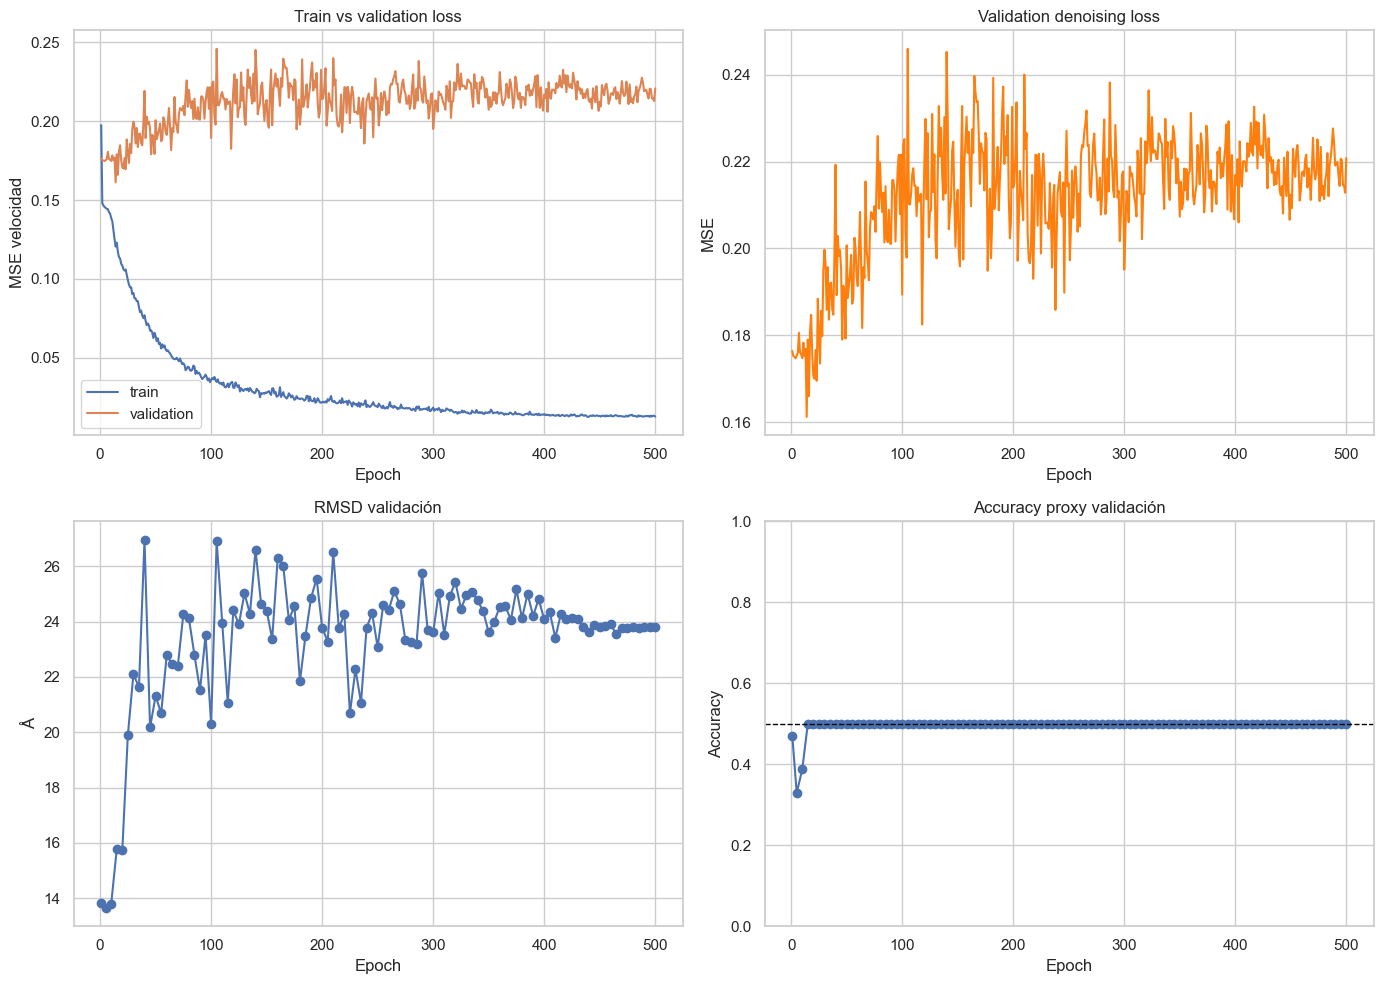

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0,0].plot(history_df.epoch, history_df.train_denoising_loss, label="train")
axes[0,0].plot(history_df.epoch, history_df.validation_denoising_loss, label="validation")
axes[0,0].set(title="Train vs validation loss", xlabel="Epoch", ylabel="MSE velocidad"); axes[0,0].legend()
axes[0,1].plot(history_df.epoch, history_df.validation_denoising_loss, color="tab:orange")
axes[0,1].set(title="Validation denoising loss", xlabel="Epoch", ylabel="MSE")
observed = history_df.dropna(subset=["validation_rmsd"])
axes[1,0].plot(observed.epoch, observed.validation_rmsd, marker="o")
axes[1,0].set(title="RMSD validación", xlabel="Epoch", ylabel="Å")
acc = history_df.dropna(subset=["validation_accuracy"])
axes[1,1].plot(acc.epoch, acc.validation_accuracy, marker="o")
axes[1,1].axhline(.5, color="black", ls="--", lw=1)
axes[1,1].set(title="Accuracy proxy validación", xlabel="Epoch", ylabel="Accuracy", ylim=(0,1))
fig.tight_layout()
fig.savefig(FIGURES_DIR / "training_curves.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Testing final

El TM-score se aproxima sobre los puntos remuestreados ya correspondidos:
`mean(1 / (1 + (d_i/d0)^2))`. No sustituye TM-align y se reporta como `approx_tm_score`.

In [10]:
def approximate_tm_score(pred, target, scale):
    n = pred.shape[1]
    d0 = max(0.5, 1.24 * np.cbrt(max(n - 15, 1)) - 1.8)
    distances = torch.linalg.vector_norm((pred-target)*scale[:,None,None], dim=-1)
    return (1 / (1 + (distances/d0)**2)).mean(-1)

@torch.no_grad()
def evaluate_test(model, loader):
    rows, loss_values = [], []
    for raw in tqdm(loader, desc="Evaluando test"):
        batch = move_batch(raw)
        loss_values.append(float(flow_loss(model, batch, training=False)))
        generated = integrate(model, batch)[1.0]
        metrics = coordinate_metrics(generated, raw["x1"], raw["scale"])
        tm = approximate_tm_score(generated, raw["x1"], raw["scale"])
        for i in range(len(generated)):
            generated_ang = (generated[i] * raw["scale"][i]).numpy()
            target_label = int(raw["target_state_name"][i] == "active")
            predicted_label = int(state_classifier.predict(state_features(generated_ang)[None])[0])
            rows.append({
                "pair_id": raw["pair_id"][i], "kinase_name": raw["kinase_name"][i],
                "source_pdb": raw["source_pdb"][i], "target_pdb": raw["target_pdb"][i],
                "direction": raw["condition"][i],
                "rmsd": float(metrics["rmsd"][i]), "mae": float(metrics["mae"][i]),
                "mse": float(metrics["mse"][i]),
                "mean_residue_distance": float(metrics["mean_residue_distance"][i]),
                "approx_tm_score": float(tm[i]),
                "state_correct": int(predicted_label == target_label),
            })
    return pd.DataFrame(rows), float(np.mean(loss_values))

test_details, final_denoising_loss = evaluate_test(model, loaders["test"])
test_details.to_csv(METRICS_DIR / "test_per_sample.csv", index=False)
summary = test_details.groupby("direction").agg(
    n_samples=("rmsd","size"), rmsd_mean=("rmsd","mean"), rmsd_std=("rmsd","std"),
    mae=("mae","mean"), mse=("mse","mean"),
    mean_residue_distance=("mean_residue_distance","mean"),
    approx_tm_score=("approx_tm_score","mean"), accuracy=("state_correct","mean")
).reset_index()
summary["denoising_loss"] = final_denoising_loss
summary["observations"] = np.where(
    (summary["accuracy"] > .5) & (summary["approx_tm_score"] > .5),
    "Señal favorable; revisar RMSD y baseline fuente-target.",
    "Evidencia insuficiente o débil para afirmar traducción."
)
summary.to_csv(METRICS_DIR / "test_summary.csv", index=False)
print(f"Denoising loss final test: {final_denoising_loss:.6f}")
display(summary)

Evaluando test: 100%|██████████| 18/18 [00:33<00:00,  1.86s/it]

Denoising loss final test: 0.183119


,direction,n_samples,rmsd_mean,rmsd_std,mae,mse,mean_residue_distance,approx_tm_score,accuracy,denoising_loss,observations
0,active_to_inactive,103,22.479379,9.165819,9.70386,196.173020,19.495565,0.201104,1.000000,0.183119,Evidencia insuficiente o débil para afirmar tr...
1,inactive_to_active,103,21.899253,9.103522,9.50621,187.215586,19.100866,0.203411,0.048544,0.183119,Evidencia insuficiente o débil para afirmar tr...


## 7. Visualización ruido → transporte/denoising → generación

En Flow Matching la trayectoria aprendida es un transporte ODE, no el reverse diffusion de un
modelo DDPM. La figura incluye una versión ruidosa de la fuente para inspeccionar la perturbación
usada en entrenamiento y los estados intermedios producidos por integración.

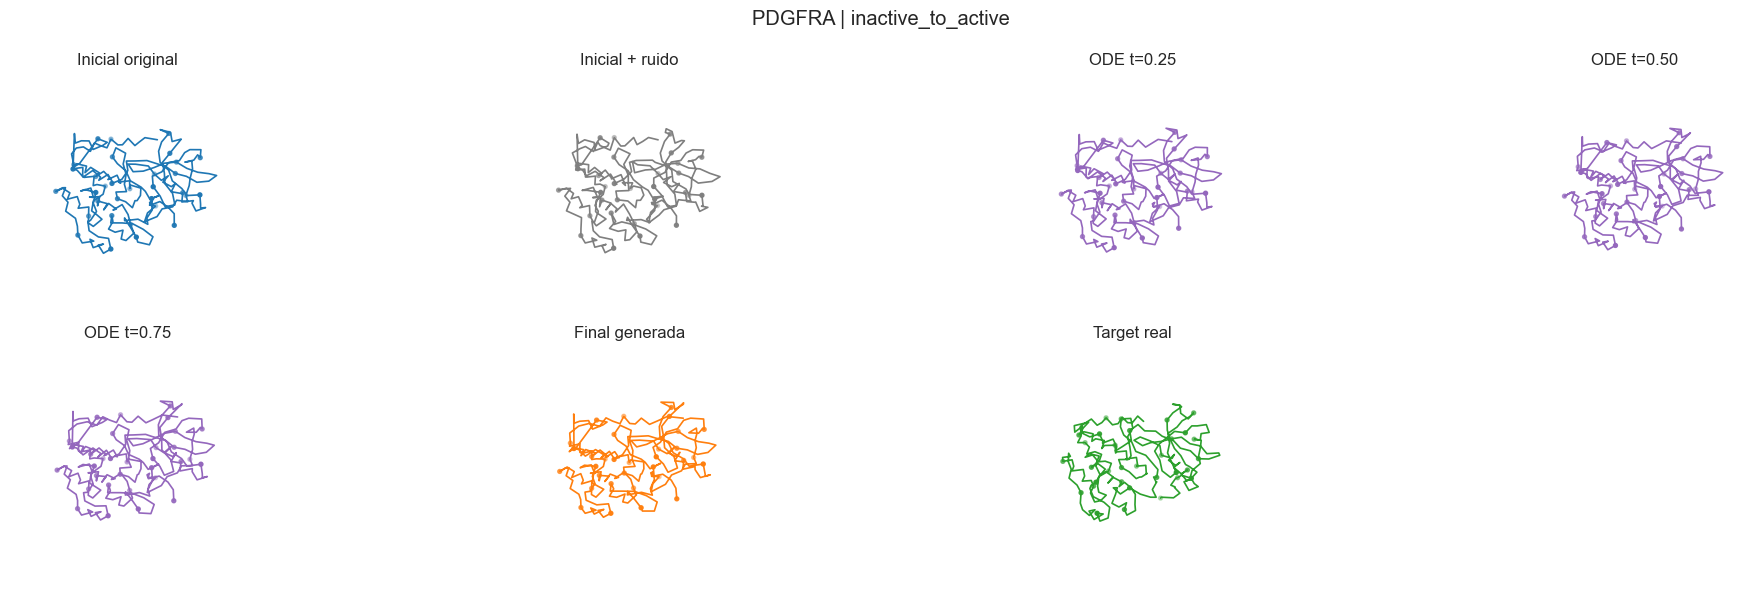

In [11]:
def set_equal_3d(ax, xyz):
    center_ = xyz.mean(0); radius = max(np.ptp(xyz, axis=0).max()/2, 1e-6)
    ax.set_xlim(center_[0]-radius, center_[0]+radius)
    ax.set_ylim(center_[1]-radius, center_[1]+radius)
    ax.set_zlim(center_[2]-radius, center_[2]+radius)

def plot_trace(ax, coords, title, color):
    ax.plot(coords[:,0], coords[:,1], coords[:,2], color=color, lw=1.2)
    ax.scatter(coords[::8,0], coords[::8,1], coords[::8,2], color=color, s=8)
    ax.set_title(title); ax.set_axis_off(); set_equal_3d(ax, coords)

example_raw = next(iter(loaders["test"]))
example = {key: (value[:1] if torch.is_tensor(value) else value[:1]) for key, value in example_raw.items()}
example_device = move_batch(example)
trajectory = integrate(model, example_device, save_times=(0,.25,.5,.75,1))
scale = float(example["scale"][0])
source = example["x0"][0].numpy()*scale
target = example["x1"][0].numpy()*scale
noisy = source + np.random.default_rng(CONFIG.seed).normal(0, CONFIG.noise_std*scale, source.shape)

panels = [
    (source, "Inicial original", "tab:blue"),
    (noisy, "Inicial + ruido", "tab:gray"),
    (trajectory[.25][0].numpy()*scale, "ODE t=0.25", "tab:purple"),
    (trajectory[.5][0].numpy()*scale, "ODE t=0.50", "tab:purple"),
    (trajectory[.75][0].numpy()*scale, "ODE t=0.75", "tab:purple"),
    (trajectory[1.][0].numpy()*scale, "Final generada", "tab:orange"),
    (target, "Target real", "tab:green"),
]
fig = plt.figure(figsize=(21, 6))
for idx, (coords, title, color) in enumerate(panels, 1):
    plot_trace(fig.add_subplot(2, 4, idx, projection="3d"), coords, title, color)
fig.suptitle(f"{example['kinase_name'][0]} | {example['condition'][0]}")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "noise_to_generation_process.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. Comparación visual inicial vs generada vs target

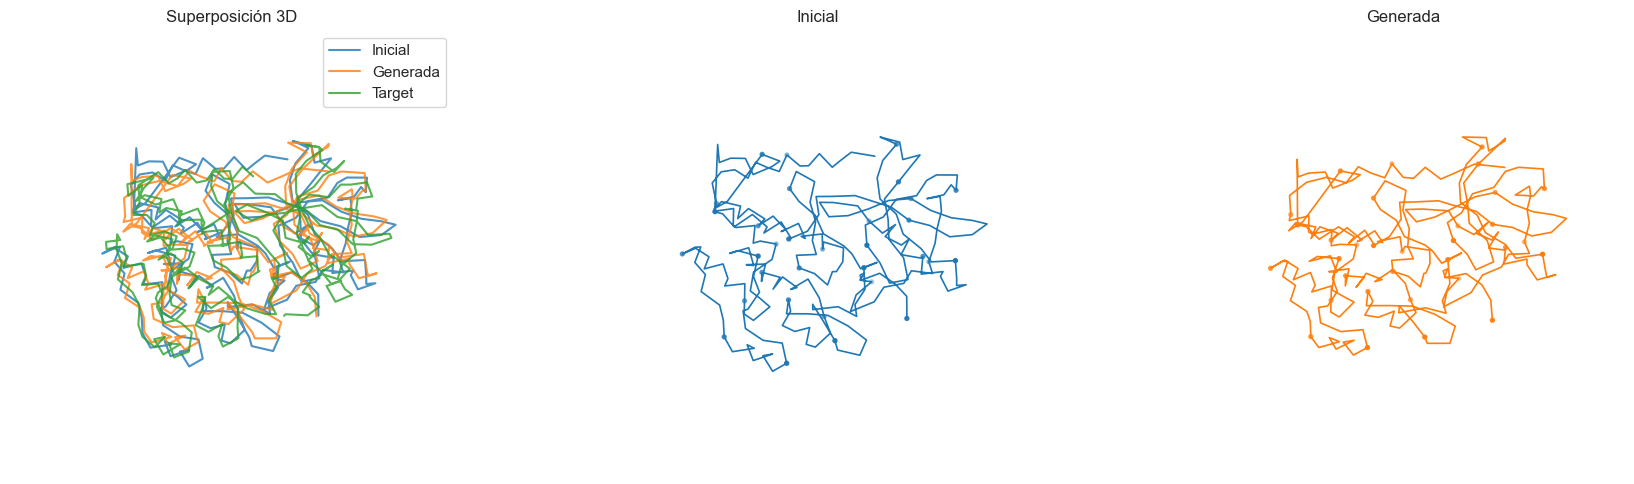

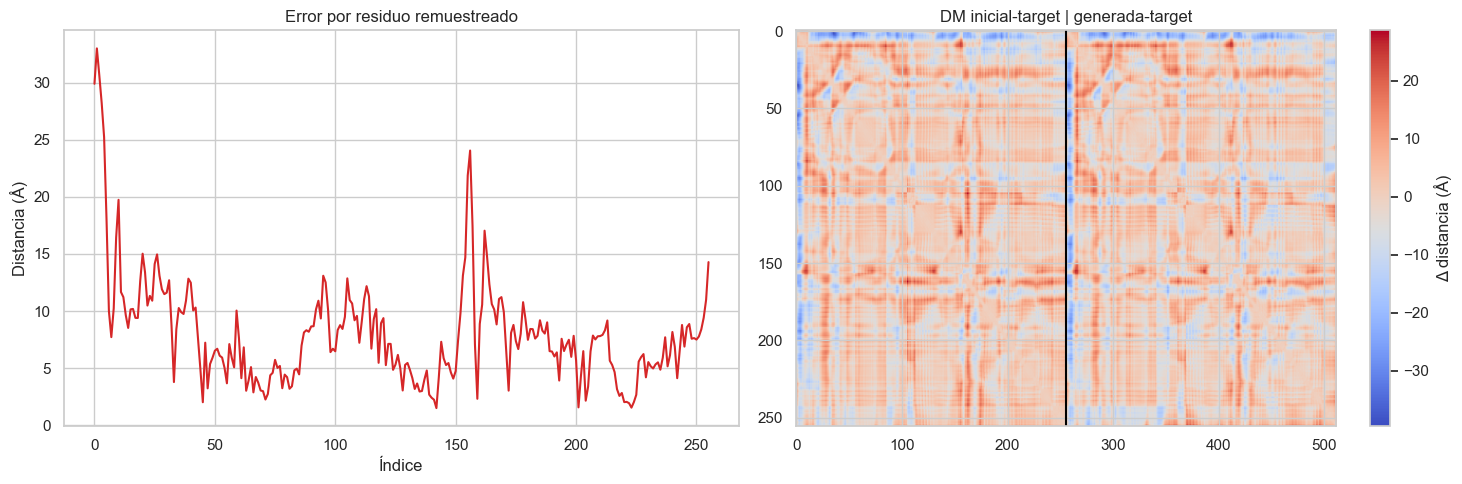

In [12]:
def distance_matrix(coords): return np.linalg.norm(coords[:,None]-coords[None,:], axis=-1)

def plot_translation_comparison(source, generated, target, name="test_example"):
    fig = plt.figure(figsize=(18, 5))
    ax = fig.add_subplot(1,3,1,projection="3d")
    for xyz, label, color in [(source,"Inicial","tab:blue"),(generated,"Generada","tab:orange"),(target,"Target","tab:green")]:
        ax.plot(xyz[:,0],xyz[:,1],xyz[:,2],label=label,color=color,alpha=.8)
    ax.legend(); ax.set_title("Superposición 3D"); ax.set_axis_off(); set_equal_3d(ax, np.vstack([source,generated,target]))
    for pos, (xyz,title,color) in enumerate([(source,"Inicial","tab:blue"),(generated,"Generada","tab:orange")],2):
        plot_trace(fig.add_subplot(1,3,pos,projection="3d"),xyz,title,color)
    fig.tight_layout(); fig.savefig(FIGURES_DIR/f"{name}_3d.png",dpi=200,bbox_inches="tight"); plt.show()

    error = np.linalg.norm(generated-target,axis=-1)
    fig, axes = plt.subplots(1,2,figsize=(15,5))
    axes[0].plot(error,color="tab:red"); axes[0].set(title="Error por residuo remuestreado",xlabel="Índice",ylabel="Distancia (Å)")
    matrices = [distance_matrix(x) for x in [source,generated,target]]
    diff = np.concatenate([matrices[0]-matrices[2], matrices[1]-matrices[2]],axis=1)
    im=axes[1].imshow(diff,cmap="coolwarm",aspect="auto")
    axes[1].axvline(len(source)-.5,color="black"); axes[1].set_title("DM inicial-target | generada-target")
    fig.colorbar(im,ax=axes[1],label="Δ distancia (Å)")
    fig.tight_layout(); fig.savefig(FIGURES_DIR/f"{name}_errors.png",dpi=200,bbox_inches="tight"); plt.show()

generated = trajectory[1.][0].numpy()*scale
plot_translation_comparison(source, generated, target)
np.savez_compressed(
    EXAMPLES_DIR / "test_example_coordinates.npz",
    source=source, noisy=noisy, generated=generated, target=target,
    **{f"trajectory_t{time:.2f}": value[0].numpy()*scale for time,value in trajectory.items()}
)

## 9. Conclusión automática basada en métricas

La conclusión exige mejora frente a copiar la estructura inicial, no solo un valor absoluto del modelo.

In [13]:
@torch.no_grad()
def source_target_baseline(loader):
    rows=[]
    for raw in loader:
        metric = coordinate_metrics(raw["x0"], raw["x1"], raw["scale"])
        for i in range(len(raw["x0"])):
            rows.append({"direction":raw["condition"][i],"source_copy_rmsd":float(metric["rmsd"][i])})
    return pd.DataFrame(rows).groupby("direction").source_copy_rmsd.mean()

baseline = source_target_baseline(loaders["test"])
summary["source_copy_rmsd"] = summary["direction"].map(baseline)
summary["relative_rmsd_improvement"] = (summary["source_copy_rmsd"]-summary["rmsd_mean"])/summary["source_copy_rmsd"]
learned = (
    (summary["relative_rmsd_improvement"] > 0.05)
    & (summary["accuracy"] > 0.5)
).all()
if learned:
    conclusion = (
        "Conclusión: hay evidencia cuantitativa de traducción bidireccional: ambas direcciones "
        "mejoran al menos 5% el baseline de copiar la fuente y superan azar en la accuracy proxy."
    )
else:
    failed = summary.loc[
        ~((summary["relative_rmsd_improvement"] > .05) & (summary["accuracy"] > .5)), "direction"
    ].tolist()
    conclusion = (
        "Conclusión: no hay evidencia suficiente para afirmar que el modelo aprendió la traducción "
        f"activo ↔ inactivo en ambas direcciones. Direcciones que no pasan el criterio: {failed}."
    )
print(conclusion)
display(summary)
summary.to_csv(METRICS_DIR / "test_summary.csv", index=False)
(OUTPUT_DIR / "automatic_conclusion.txt").write_text(conclusion + "\n", encoding="utf-8")
with (OUTPUT_DIR / "run_config.json").open("w", encoding="utf-8") as handle:
    json.dump({**asdict(CONFIG), "device": DEVICE, "representation": "resampled_C_alpha"}, handle, indent=2)

print("\nArchivos guardados:")
for path in sorted(OUTPUT_DIR.rglob("*")):
    if path.is_file():
        print("-", path.relative_to(ROOT))

Conclusión: no hay evidencia suficiente para afirmar que el modelo aprendió la traducción activo ↔ inactivo en ambas direcciones. Direcciones que no pasan el criterio: ['active_to_inactive', 'inactive_to_active'].


,direction,n_samples,rmsd_mean,rmsd_std,mae,mse,mean_residue_distance,approx_tm_score,accuracy,denoising_loss,observations,source_copy_rmsd,relative_rmsd_improvement
0,active_to_inactive,103,22.479379,9.165819,9.70386,196.173020,19.495565,0.201104,1.000000,0.183119,Evidencia insuficiente o débil para afirmar tr...,21.248858,-0.057910
1,inactive_to_active,103,21.899253,9.103522,9.50621,187.215586,19.100866,0.203411,0.048544,0.183119,Evidencia insuficiente o débil para afirmar tr...,21.248858,-0.030608



Archivos guardados:
- outputs/foldflow_cfg_active_inactive/automatic_conclusion.txt
- outputs/foldflow_cfg_active_inactive/checkpoints/best_model.pt
- outputs/foldflow_cfg_active_inactive/checkpoints/last_model.pt
- outputs/foldflow_cfg_active_inactive/figures/noise_to_generation_process.png
- outputs/foldflow_cfg_active_inactive/figures/test_example_3d.png
- outputs/foldflow_cfg_active_inactive/figures/test_example_errors.png
- outputs/foldflow_cfg_active_inactive/figures/training_curves.png
- outputs/foldflow_cfg_active_inactive/generated_examples/test_example_coordinates.npz
- outputs/foldflow_cfg_active_inactive/metrics/coordinate_audit.csv
- outputs/foldflow_cfg_active_inactive/metrics/dataset_summary.csv
- outputs/foldflow_cfg_active_inactive/metrics/excluded_structures.csv
- outputs/foldflow_cfg_active_inactive/metrics/paired_translation_samples.csv
- outputs/foldflow_cfg_active_inactive/metrics/split_groups.csv
- outputs/foldflow_cfg_active_inactive/metrics/test_per_sample.csv

## Limitaciones que deben acompañar los resultados

1. Los PDB se emparejan por kinasa y estado, no por una medición temporal del mismo cristal.
2. El remuestreo por índice no equivale a un alineamiento por secuencia/residuo.
3. `approx_tm_score` no es TM-align.
4. La accuracy usa un clasificador auxiliar entrenado solo con train, pero sigue siendo un proxy.
5. Un buen loss de velocidad no prueba por sí solo que la conformación generada sea biológicamente válida.
6. Para afirmar FoldFlow completo sería necesario integrar una implementación SE(3) oficial y conservar
   correspondencias de residuos/marcos rígidos en el preprocesamiento.